In [2]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from scripts.data_reader import load_and_prepare_time_series_data
from scripts.trainer import Trainer
from models.lstm import LSTMModel

In [5]:
help(load_and_prepare_time_series_data)

Help on function load_and_prepare_time_series_data in module scripts.data_reader:

load_and_prepare_time_series_data(
    filepath_or_url,
    target_column,
    date_column=None,
    seq_length=14,
    batch_size=32,
    train_split=0.8,
    fill_missing=True
)
    Downloads or read a CSV dataset, clean it, scales it, and return DataLoaders ready for training

    Arg:
        filepath_or_url (str): Path to local CSV or URL to a remote CSV.
        target_column (str): The name of the column you want to predict.
        date_column (str, optional): Column to sort chronologically
        seq_length (int, default=14): How many past steps to use for predicting the next step.
        batch_size (int, default=32): Size of the batches for the DataLoaders.
        train_split (float, default=0.8): Ratio of data to use for training (0 to 1)
        fill_missing (bool): If True, forward-fills and zero-fills missing data.



In [7]:
data_url = "https://storage.googleapis.com/covid19-open-data/v3/location/US.csv"

# Safely unpack the data reader results regardless of which version you have
results = load_and_prepare_time_series_data(
    filepath_or_url=data_url,
    target_column="new_confirmed",
    date_column="date",
    seq_length=14,
    batch_size=32,
    train_split=0.8,
    fill_missing=True
)

train_loader, val_loader, val_dataset, scaler = results


Fetching data from: https://storage.googleapis.com/covid19-open-data/v3/location/US.csv
Sorting data chronologicall by column: date
Succesfully loaded 991 sequential data points.
Prepared Training batches: 25 | Validation batches: 6


In [ ]:
model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1)   
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        device="cpu"
    )
trainer.train(train_loader=train_loader, val_loader=val_loader, epochs=1000)

Starting training on device: cpu
Epoch 1/1000 | Train Loss: 0.0026 | Val Loss: 0.0014
Epoch 2/1000 | Train Loss: 0.0024 | Val Loss: 0.0015
Epoch 3/1000 | Train Loss: 0.0022 | Val Loss: 0.0015
Epoch 4/1000 | Train Loss: 0.0027 | Val Loss: 0.0015
Epoch 5/1000 | Train Loss: 0.0023 | Val Loss: 0.0017
Epoch 6/1000 | Train Loss: 0.0025 | Val Loss: 0.0015
Epoch 7/1000 | Train Loss: 0.0026 | Val Loss: 0.0026
Epoch 8/1000 | Train Loss: 0.0032 | Val Loss: 0.0015
Epoch 9/1000 | Train Loss: 0.0022 | Val Loss: 0.0015
Epoch 10/1000 | Train Loss: 0.0023 | Val Loss: 0.0018
Epoch 11/1000 | Train Loss: 0.0023 | Val Loss: 0.0015
Epoch 12/1000 | Train Loss: 0.0022 | Val Loss: 0.0016
Epoch 13/1000 | Train Loss: 0.0022 | Val Loss: 0.0016
Epoch 14/1000 | Train Loss: 0.0024 | Val Loss: 0.0015
Epoch 15/1000 | Train Loss: 0.0021 | Val Loss: 0.0015
Epoch 16/1000 | Train Loss: 0.0025 | Val Loss: 0.0017
Epoch 17/1000 | Train Loss: 0.0024 | Val Loss: 0.0015
Epoch 18/1000 | Train Loss: 0.0027 | Val Loss: 0.0018
Epoc

([0.00257355714178522,
  0.002353145825357301,
  0.00222558911083563,
  0.00271362134142944,
  0.0022775837163989143,
  0.0025468181341316114,
  0.0026121441380223764,
  0.0031720493826775747,
  0.0022344741080576377,
  0.0023336057509457248,
  0.0023275095248800775,
  0.0022153468272268083,
  0.002240254585619221,
  0.0024386756823896157,
  0.002119072418590196,
  0.002522181354733639,
  0.0024221892718370563,
  0.002743570687091289,
  0.0026202228361415104,
  0.0025175955759452365,
  0.0022918927557853226,
  0.002018127189997038,
  0.0020106927880997575,
  0.0018433753855666803,
  0.001842460727048583,
  0.0018034662539917487,
  0.0018212046008257814,
  0.0017219076974851325,
  0.0016285335892873665,
  0.001643988516694653,
  0.0014999200243402302,
  0.0014439878545660803,
  0.0015562945156260023,
  0.0014659327524145563,
  0.001466956226619626,
  0.0015627758471300625,
  0.0015109367757660977,
  0.0014395937244264185,
  0.0013808033925946203,
  0.001241105893320957,
  0.001450112237

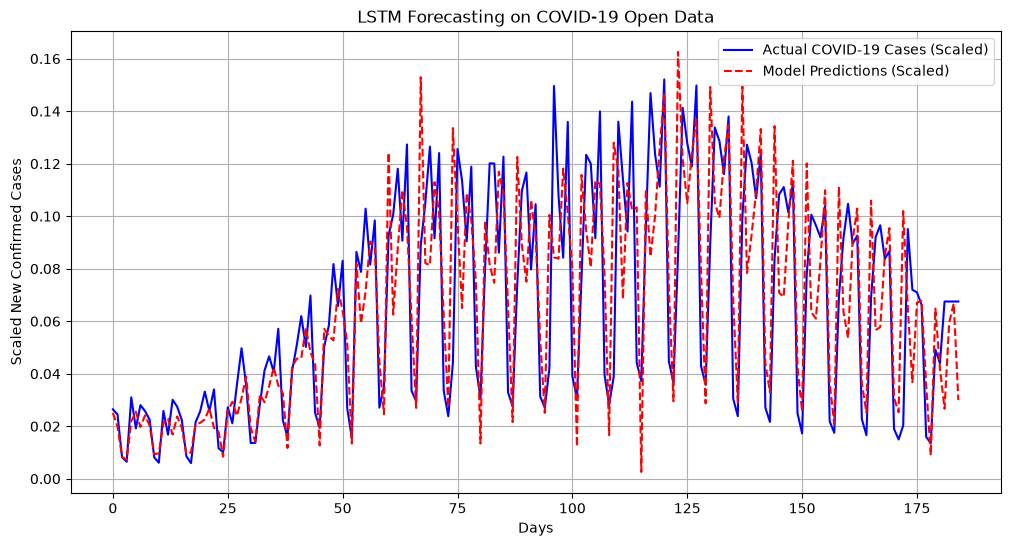

In [16]:
model.eval()
    
actuals = []
predictions = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(trainer.device)
        preds = model(batch_x)
        
        actuals.extend(batch_y.cpu().numpy().flatten())
        predictions.extend(preds.cpu().numpy().flatten())
        
# Plotting the validation data
plt.figure(figsize=(12, 6))
plt.plot(actuals, label="Actual COVID-19 Cases (Scaled)", color="blue")
plt.plot(predictions, label="Model Predictions (Scaled)", color="red", linestyle="--")
plt.title("LSTM Forecasting on COVID-19 Open Data")
plt.xlabel("Days")
plt.ylabel("Scaled New Confirmed Cases")
plt.legend()
plt.grid(True)
plt.show()